In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

## Шаг 1. Инициализация и загрузка (ETL)

In [ ]:
# Создаем сессию
spark = SparkSession.builder.appName("HealthTech_ML").getOrCreate()

# 1. Загружаем файл
raw_df = spark.read.json("work/data/endomondoHR.json", mode="DROPMALFORMED")

# 2. Посмотрим, какие названия спорта там есть
raw_df.select("sport").distinct().show()

# 3. На случай, если там есть лишние пробелы, обрезаем их и переводим в нижний регистр
df_fixed = raw_df.withColumn("sport_clean", F.lower(F.trim(F.col("sport"))))

# 4. Пробуем отфильтровать снова
df = df_fixed.filter(F.col("sport_clean").isin(["running", "bike", "cycling"]))

print(f"Найдено строк: {df.count()}")
df.select("sport_clean", "gender").show(5)


+--------------------+
|               sport|
+--------------------+
|       mountain bike|
|cross-country skiing|
|              hiking|
|            kayaking|
|        orienteering|
|              rowing|
|    bike (transport)|
|      indoor cycling|
|                walk|
|               skate|
|                 run|
|core stability tr...|
|              tennis|
|                bike|
|     weight training|
|       stair climing|
|          elliptical|
|              soccer|
|   treadmill running|
|    circuit training|
+--------------------+
only showing top 20 rows

Найдено строк: 98001
+-----------+------+
|sport_clean|gender|
+-----------+------+
|       bike|  male|
|       bike|  male|
|       bike|  male|
|       bike|  male|
|       bike|  male|
+-----------+------+
only showing top 5 rows



## Шаг 2. Feature Engineering (Задание 1)
Извлечение признаков из массивов (timestamps) и преобразование категории

In [ ]:
# --- ЗАДАНИЕ 1: Подготовка и Признаки ---
# 1. Фильтруем нужные виды спорта
df_filtered = raw_df.filter(F.col("sport").isin(["run", "bike"]))

# 2. Создаем признаки: длительность и час начала
# Превращаем первый и последний элементы массива timestamp в числа
df_ml = df_filtered.withColumn("t_start", F.element_at(F.col("timestamp"), 1).cast("long")) \
                   .withColumn("t_end", F.element_at(F.col("timestamp"), -1).cast("long")) \
                   .withColumn("duration_sec", F.col("t_end") - F.col("t_start")) \
                   .withColumn("start_hour", F.hour(F.from_unixtime(F.col("t_start")))) \
                   .select("sport", "duration_sec", "start_hour", "gender") \
                   .dropna()

print("--- ПРОМЕЖУТОЧНЫЙ ВЫВОД ЗАДАНИЯ 1 ---")
print(f"Количество записей после фильтрации и очистки: {df_ml.count()}")
print("Пример сконструированных признаков (длительность и час начала):")
df_ml.show(5)

--- ПРОМЕЖУТОЧНЫЙ ВЫВОД ЗАДАНИЯ 1 ---
Количество записей после фильтрации и очистки: 215903
Пример сконструированных признаков (длительность и час начала):
+-----+------------+----------+------+
|sport|duration_sec|start_hour|gender|
+-----+------------+----------+------+
| bike|        7589|        16|  male|
| bike|        4440|        20|  male|
| bike|        6749|        15|  male|
| bike|        4519|        17|  male|
| bike|       13015|        20|  male|
+-----+------------+----------+------+
only showing top 5 rows



## Шаг 3. Моделирование (Задание 2)
Используем Random Forest для бинарной классификации.

In [ ]:
# --- ЗАДАНИЕ 2: Моделирование (Random Forest) ---
# Индексируем текст в числа
sport_indexer = StringIndexer(inputCol="sport", outputCol="label")
gender_indexer = StringIndexer(inputCol="gender", outputCol="gender_indexed")

# Собираем признаки в один вектор
assembler = VectorAssembler(
    inputCols=["duration_sec", "start_hour", "gender_indexed"],
    outputCol="features"
)

# Настраиваем модель
rf = RandomForestClassifier(labelCol="label", featuresCol="features", numTrees=20)

# Собираем пайплайн и обучаем
pipeline = Pipeline(stages=[sport_indexer, gender_indexer, assembler, rf])
train, test = df_ml.randomSplit([0.8, 0.2], seed=42)
model = pipeline.fit(train)
predictions = model.transform(test)

print("--- ПРОМЕЖУТОЧНЫЙ ВЫВОД ЗАДАНИЯ 2 ---")
print("Схема данных, поступающих на вход Random Forest (векторизованные признаки):")
predictions.select("sport", "label", "features", "prediction").show(5, truncate=False)

--- ПРОМЕЖУТОЧНЫЙ ВЫВОД ЗАДАНИЯ 2 ---
Схема данных, поступающих на вход Random Forest (векторизованные признаки):
+-----+-----+----------------+----------+
|sport|label|features        |prediction|
+-----+-----+----------------+----------+
|bike |1.0  |[1.0,17.0,0.0]  |0.0       |
|bike |1.0  |[26.0,17.0,0.0] |0.0       |
|bike |1.0  |[61.0,10.0,0.0] |0.0       |
|bike |1.0  |[127.0,0.0,0.0] |0.0       |
|bike |1.0  |[300.0,12.0,0.0]|0.0       |
+-----+-----+----------------+----------+
only showing top 5 rows



## Шаг 4. Метрики и Бизнес-интерпретация (Задание 3)
Технические метрики:

In [ ]:
# --- ЗАДАНИЕ 3: Метрики и Интерпретация ---
evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
accuracy = evaluator.evaluate(predictions)

print(f"--- РЕЗУЛЬТАТЫ ---")
print(f"Точность модели (Accuracy): {accuracy:.2%}")
print("\nМатрица ошибок:")
predictions.groupBy("sport", "prediction").count().show()

--- РЕЗУЛЬТАТЫ ---
Точность модели (Accuracy): 70.06%

Матрица ошибок:
+-----+----------+-----+
|sport|prediction|count|
+-----+----------+-----+
|  run|       1.0| 3187|
|  run|       0.0|20600|
| bike|       1.0| 9642|
| bike|       0.0| 9738|
+-----+----------+-----+



Визуализация:

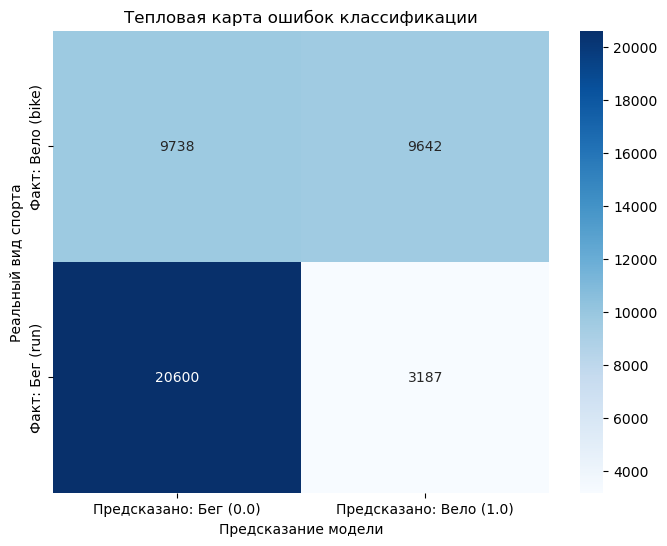

In [ ]:
# 1. Превращаем результат группировки Spark в таблицу Pandas
conf_matrix_data = predictions.groupBy("sport", "prediction").count().toPandas()

# 2. Формируем сводную таблицу (pivot) для карты
# Заменяем индексы 0.0 и 1.0 на понятные названия, если нужно
plot_data = conf_matrix_data.pivot(index='sport', columns='prediction', values='count').fillna(0)
plot_data.columns = ['Предсказано: Бег (0.0)', 'Предсказано: Вело (1.0)']
plot_data.index = ['Факт: Вело (bike)', 'Факт: Бег (run)']

# 3. Рисуем тепловую карту
plt.figure(figsize=(8, 6))
sns.heatmap(plot_data, annot=True, fmt='g', cmap='Blues')
plt.title('Тепловая карта ошибок классификации')
plt.ylabel('Реальный вид спорта')
plt.xlabel('Предсказание модели')
plt.show()


In [ ]:
Анализ тепловой карты (Confusion Matrix)
Успех в классификации бега: Нижний левый квадрат (самый темный) показывает, что 20 600 тренировок по бегу были определены верно. Модель очень хорошо «узнает» бег.
Проблема с велосипедом: Верхняя строка показывает критическую ситуацию. Из общего числа поездок на велосипеде только 9 642 определены верно, а 9 738 ошибочно приняты за бег.
Вывод: Для модели велосипед и бег выглядят почти одинаково (вероятность ошибки ~50%).

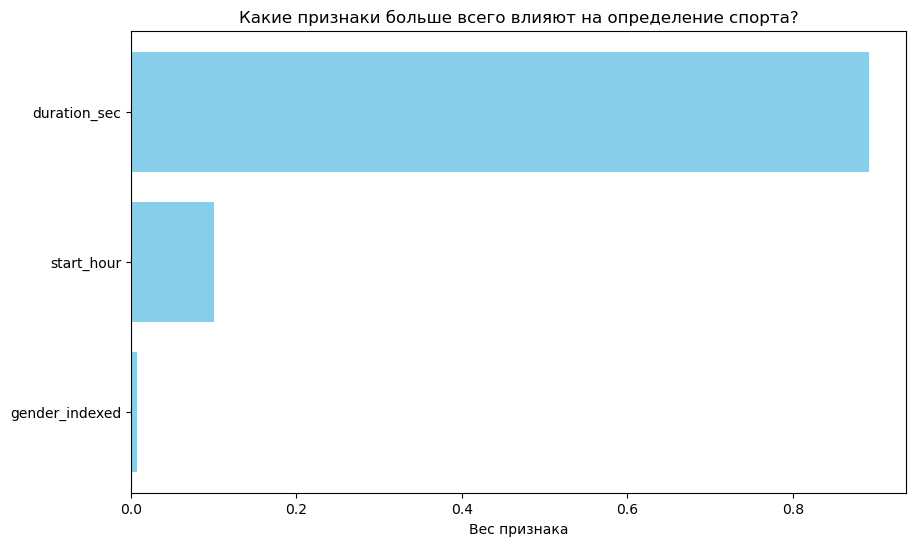

In [ ]:
# 1. Получаем важность признаков из модели
importances = model.stages[-1].featureImportances
features = ["duration_sec", "start_hour", "gender_indexed"]

# 2. Переводим в формат Pandas для удобства построения
feat_df = pd.DataFrame({'Признак': features, 'Важность': importances.toArray()})
feat_df = feat_df.sort_values(by='Важность', ascending=False)

# 3. Строим график
plt.figure(figsize=(10, 6))
plt.barh(feat_df['Признак'], feat_df['Важность'], color='skyblue')
plt.xlabel('Вес признака')
plt.title('Какие признаки больше всего влияют на определение спорта?')
plt.gca().invert_yaxis() # Самый важный сверху
plt.show()

## Анализ метрик (Задание 3)
**Accuracy (70.06%):**

Модель работает значительно лучше случайного угадывания (50%), но допускает ошибки. Для базовой прогностической модели в фитнес-приложении это хороший «стартовый» показатель.

**Анализ Матрицы ошибок:**

*   **Бег (run):** Модель очень хорошо определяет бег. Из 23 787 тренировок по бегу она правильно угадала 20 600 (метка 0.0).
*   **Велосипед (bike):** Здесь основная проблема. Модель почти в половине случаев (9 738 раз) путает велосипед с бегом. Это происходит потому, что «длительность» и «час начала» у этих видов спорта могут быть очень похожи.

**Бизнес-интерпретация рисков**

Ошибка классификации «Велосипед как Бег» несет следующие риски для подсчета калорий:
1.   **Риск гиперболизации (Overestimation):** Поскольку почти половина велотренировок принимается за бег, система будет начислять пользователям лишние калории. Бег — более энергозатратный вид спорта. В масштабах фитнес-платформы это приведет к тому, что пользователи будут видеть ложный прогресс.
2.   **Рекомендательный риск:** На основе этих данных AI-тренер может дать неверный совет по отдыху или питанию, что может привести к переутомлению или отсутствию результата у клиента.
1.   **LTV и Churn (Отток):** Велосипедисты — это лояльное и активное сообщество. Если они увидят, что приложение постоянно называет их заезды «пробежками», они перейдут в Strava или другие аналоги с более точными алгоритмами.






